In [1]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [5]:
from model.metrics import MSE, MAE, evaluate_linear_regression
from model.gradients import MSE_grad#, MAE_grad
from model.utils import *
import matplotlib.pyplot as plt

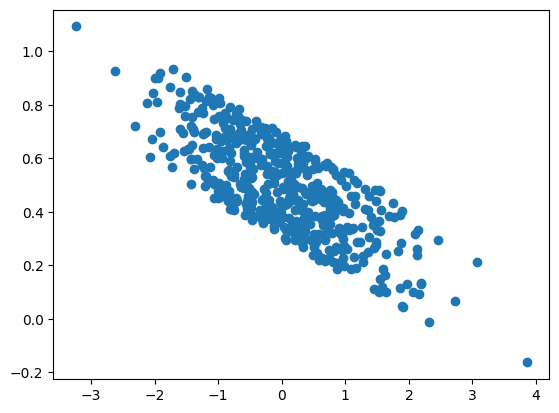

In [6]:
# Sample Code for generating datasets
seed=42
np.random.seed(seed)
size = 500
dim = 1
noise_bound = 0.2
X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=True)
plt.scatter(X[:,1],y)

X size : (8000, 6), y size : (8000,)
50. Training loss: 2.304087892398808, Val loss:2.322128048766163
100. Training loss: 1.8985450836883995, Val loss:1.9158913872329326
150. Training loss: 1.5671407025131152, Val loss:1.583651269816583
200. Training loss: 1.2963007550181984, Val loss:1.311900911601199
250. Training loss: 1.0749402753827337, Val loss:1.089603421914175
300. Training loss: 0.8940062289510703, Val loss:0.907739402458882
350. Training loss: 0.746104485102115, Val loss:0.7589375407399721
400. Training loss: 0.6251953745771189, Val loss:0.6371729496861158
450. Training loss: 0.5263452025213162, Val loss:0.5375208103389395
500. Training loss: 0.44552341732277034, Val loss:0.4559551633623018


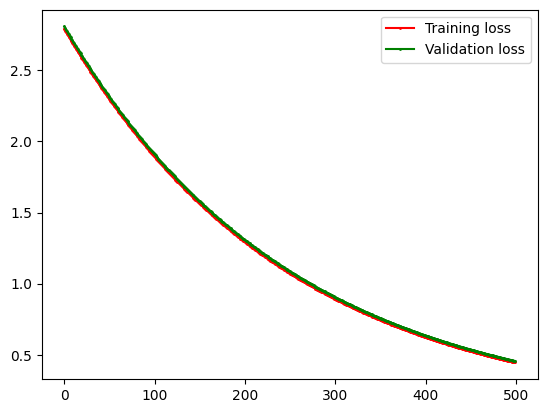

=== Linear Regression Evaluation ===
MSE       : 0.4475
MAE       : 0.5415
RMSE      : 0.6690
R-squared : 0.8458


{'MSE': np.float64(0.447540024570337),
 'MAE': 0.5415153727811028,
 'RMSE': np.float64(0.6689843231125353),
 'R-squared': 0.8457672431067151}

In [43]:
# for Q1

# Loading data
loaded_data = np.load(f'data/linear_data/linear_data_D.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1

# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function and gradient. 
loss_fn = MSE
grad_fn = MSE_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,True,loss_fn,grad_fn)
model.fit(X_train,y_train,lr=0.001,n_iteration =500,val_ratio=0.2)

# Get the Prediction
y_val_pred = model.predict(X_val)

# Evaluation 
# Please complete the evaluate_linear_regression in the model/metrics.py by the sklearn package.
evaluate_linear_regression(y_true=y_val,y_pred=y_val_pred,title='Linear Regression Evaluation')

In [27]:
# Loading data
loaded_data = np.load(f'data/linear_data/linear_data_B.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1

X size : (1600, 2), y size : (1600,)


50. Training loss: 1.371673141563389, Val loss:1.3915690411645854
100. Training loss: 1.1725121323450383, Val loss:1.185792500400312
150. Training loss: 1.0076380300479466, Val loss:1.0155240745606382
200. Training loss: 0.8711479141554356, Val loss:0.8746422988297105
250. Training loss: 0.7581551624933356, Val loss:0.7580805514604568
300. Training loss: 0.6646144696871166, Val loss:0.6616453213702442
350. Training loss: 0.5871769943729133, Val loss:0.581865782946438
400. Training loss: 0.5230704472905523, Val loss:0.5158692847835491
450. Training loss: 0.4699998257287622, Val loss:0.46127828819686856
500. Training loss: 0.42606523929518103, Val loss:0.4161250604089985


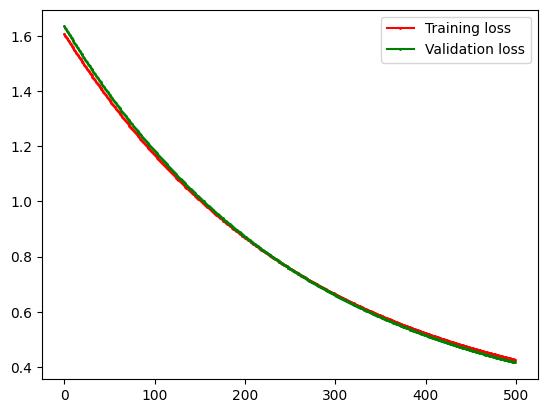

,dim,1
,is_reg,True
,loss_fn,<function MSE...x761cfe7893a0>
,grad_fn,<function MSE...x761ca67d5300>
,act_fn,<function Lin...x761ca5997560>
,lr,0.1
,reg_type,''
,reg_lambda,0
,n_iteration,50
,val_ratio,0.2
,random_state,None


In [35]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function and gradient. 
loss_fn = MSE
grad_fn = MSE_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,True,loss_fn,grad_fn)
model.fit(X_train,y_train,lr=0.001,n_iteration =500,val_ratio=0.2)

In [36]:
# Get the Prediction
y_val_pred = model.predict(X_val)

In [37]:
# Evaluation 
# Please complete the evaluate_linear_regression in the model/metrics.py by the sklearn package.
evaluate_linear_regression(y_true=y_val,y_pred=y_val_pred,title='Linear Regression Evaluation')

=== Linear Regression Evaluation ===
MSE       : 0.3920
MAE       : 0.5172
RMSE      : 0.6261
R-squared : -0.7521


{'MSE': np.float64(0.3919804703051565),
 'MAE': 0.5172346537344978,
 'RMSE': np.float64(0.6260834371752351),
 'R-squared': -0.7521153671200671}

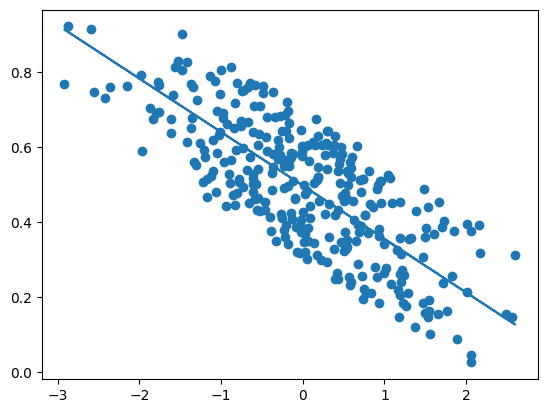

In [ ]:
# Plot
plt.scatter(X_val[:,1],y_val)
plt.plot(X_val[:,1],y_val_pred)
plt.show()